# **NLP - The Ghost in the Machine** 

This project involves a series of subtasks that revolve around human/AI authorship detection, each of which walks through the process of training a model in a particular task. The task's central problem is not just merely about detection, but if a particularly styled prompt generates text that has statistical fingerprints, whether it can bypass detection, and how well the model can train based on this. The following is the structure of the project:

Task 0 - Dataset construction  
Task 1 - Computation of statistical values for the dataset  
Task 2 - Building and training of multiple classifiers of increasing theoretical accuracy  
Task 3 - Interpretability  
Task 4 - Tricking the model


## **Task 0 - The Library of Babel**

### Task 0.1 — Preparing Human Text

This step cleans raw Project Gutenberg texts by removing headers, footers, and formatting noise, then splits each book into fixed-size paragraph chunks.

**How to run:**
- Place raw `.txt` books in `data/raw/`
- Run the cell once
- Cleaned and chunked text will be saved to `data/clean/` and `data/human/`

**Libraries used:**
- `re`, `pathlib`, `collections` (standard Python utilities)

In [3]:
import re
import string
from pathlib import Path
from collections import Counter

root=Path.cwd().parent
pathraw=root/"data"/"raw"
pathcleaned=root/"data"/"clean"
pathchunked=root/"data"/"human"

def splitsentence(sentence):
    return re.split(r'(?<=[.!?])\s+',sentence)

def chunkpara(text,maxwords=500):
    sentences=splitsentence(text)
    chunks,current,count=[],[],0
    for s in sentences:
        current.append(s)
        count+=len(s.split())
        if count>=maxwords:
            chunks.append(" ".join(current))
            current,count=[],0
    if current:
        chunks.append(" ".join(current))
    return chunks

def findstart(lines):
    for i in range(len(lines)-2):
        if all(len(l)>50 and any(c.islower() for c in l) for l in lines[i:i+3]):
            return i
    return 0

def normalize(lines):
    cleaned,blank=[],False
    for line in lines:
        line=line.strip()
        if not line:
            if not blank:
                cleaned.append("")
            blank=True
        else:
            cleaned.append(line)
            blank=False
    return cleaned

def clean(path):
    text=path.read_text(encoding="utf-8").splitlines()
    start,end=0,len(text)
    for i,line in enumerate(text):
        if "*** START" in line.upper():
            start=i+1
        if "*** END" in line.upper():
            end=i
            break
    text=normalize(text[start:end])
    return text[findstart(text):]

def prepare():
    pathcleaned.mkdir(parents=True,exist_ok=True)
    pathchunked.mkdir(parents=True,exist_ok=True)

    for file in pathraw.glob("*.txt"):
        cleaned="\n".join(clean(file))
        cleanpath=pathcleaned/f"{file.stem}cleaned.txt"
        cleanpath.write_text(cleaned,encoding="utf-8")

        chunks=chunkpara(cleaned)
        base=file.stem
        for i,c in enumerate(chunks):
            (pathchunked/f"{base}chunk{i}.txt").write_text(c,encoding="utf-8")

prepare()

### Task 0.2 — Topic Extraction

This step extracts dominant topics from each book by computing TF–IDF scores over nouns and proper nouns.

**How to run:**
- Requires chunked human text in `data/human/`
- Outputs topic lists to `data/topics/`

**Libraries used:**
- `spaCy` (POS tagging)
- `math`, `json` (score computation and storage)

In [4]:
import json
import math
import spacy
from pathlib import Path
from collections import Counter

nlp=spacy.load("en_core_web_sm",disable=["parser","ner"])

root=Path.cwd().parent
pathchunked=root/"data"/"human"
pathtopics=root/"data"/"topics"

def extracttopics(topn=10):
    books={}
    for file in pathchunked.glob("*.txt"):
        key="_".join(file.stem.split("_")[:-2])
        books.setdefault(key,[]).append(file)

    tfidf={}
    docfreq=Counter()

    for book,files in books.items():
        nouncounts=Counter()
        texts=[f.read_text(encoding="utf-8") for f in files]
        for doc in nlp.pipe(texts,batch_size=50):
            for t in doc:
                if t.pos_ in ("NOUN","PROPN") and t.is_alpha and len(t.text)>3:
                    nouncounts[t.text.lower()]+=1
        tfidf[book]=nouncounts
        docfreq.update(nouncounts.keys())

    pathtopics.mkdir(parents=True,exist_ok=True)

    for book,counts in tfidf.items():
        total=sum(counts.values())
        scores={
            w:(c/total)*math.log(len(tfidf)/docfreq[w])
            for w,c in counts.items()
        }
        top=sorted(scores,key=scores.get,reverse=True)[:topn]
        (pathtopics/f"{book}topics.txt").write_text("\n".join(top))

extracttopics()

## Task 0.3 — Generating AI Paragraphs

This step uses the Gemini API to generate:
- Generic AI paragraphs
- Stylized AI paragraphs mimicking a specific author

Thread-based concurrency is used to speed up API requests.

**How to run:**
- Ensure `GEMINI_API_KEY` is set in `.env`
- Topics must exist in `data/topics/`
- Outputs are saved to `data/generic_ai/` and `data/stylized_ai/`

**Libraries used:**
- `google.generativeai`
- `concurrent.futures` (parallel requests)

In [ ]:
import os
import time
from pathlib import Path
from dotenv import load_dotenv
from google import genai as gemini
from concurrent.futures import ThreadPoolExecutor,as_completed

load_dotenv()
client=gemini.Client(api_key=os.getenv("GEMINI_API_KEY"))

root=Path.cwd().parent
pathtopics=root/"data"/"topics"
class1=root/"data"/"generic_ai"
class2=root/"data"/"stylized_ai"

def response(prompt):
    for _ in range(3):
        try:
            return client.models.generate_content(
                model="gemini-2.0-flash",
                contents=prompt
            ).text
        except Exception:
            time.sleep(5)
    raise RuntimeError("failed after retries")

def generatepair(topic,author):
    g=response(f"Write a 300-400 word paragraph about {topic}.")
    s=response(f"Write a 300-400 word paragraph about {topic} in the style of {author}.")
    return g,s

class1.mkdir(parents=True,exist_ok=True)
class2.mkdir(parents=True,exist_ok=True)

for file in pathtopics.glob("*.txt"):
    base=file.stem.replace("_topics","")
    author=" ".join(base.split("_")[:2]).title()
    topics=file.read_text().splitlines()

    for ti,topic in enumerate(topics,1):
        with ThreadPoolExecutor(max_workers=5) as ex:
            futures={
                ex.submit(generatepair,topic,author):i
                for i in range(25)
            }
            for f in as_completed(futures):
                i=futures[f]
                g,s=f.result()
                (class1/f"{base}_t{ti}_{i}.txt").write_text(g)
                (class2/f"{base}_t{ti}_{i}.txt").write_text(s)

## Task 0.4 — Balancing Dataset

This step balances the number of AI-generated samples with human-written samples by random subsampling.

**How to run:**
- Run after all text generation is complete
- Excess files are permanently deleted

**Libraries used:**
- `random`, `pathlib`

In [6]:
import random
from pathlib import Path

random.seed(42)

root=Path.cwd().parent
pathhuman=root/"data"/"human"
pathgeneric=root/"data"/"generic_ai"
pathstylized=root/"data"/"stylized_ai"

humancount=len(list(pathhuman.glob("*.txt")))
target=humancount//2

def subsample(path,n):
    files=list(path.glob("*.txt"))
    n=min(n,len(files))
    keep=set(random.sample(files,n))
    for f in files:
        if f not in keep:
            f.unlink()

subsample(pathgeneric,target)
subsample(pathstylized,target)

print("dataset balanced")

dataset balanced


## **Task 1 - The Fingerprint**

## Task 1.1 — Statistical Feature Extraction

This step computes lexical, syntactic, readability, and punctuation-based features for all text classes (human, generic AI, stylized AI).

**How to run:**
- Ensure text files exist in `data/human/`, `data/generic_ai/`, and `data/stylized_ai/`
- Run the cell once
- A CSV file containing all extracted features will be saved to `data/fingerprint_data.csv`

**Libraries used:**
- `spaCy` (POS tagging, dependency parsing)
- `textstat` (readability metrics)
- `pandas` (tabular storage)

In [7]:
import spacy
import textstat
import pandas as pd
from collections import Counter
from pathlib import Path
from tqdm import tqdm

nlp=spacy.load("en_core_web_sm")

root=Path.cwd().parent
folders={
    "human":root/"data"/"human",
    "generic_ai":root/"data"/"generic_ai",
    "stylized_ai":root/"data"/"stylized_ai"
}

def ttrhapax(doc):
    words=[t.text.lower() for t in doc if t.is_alpha]
    if not words:
        return None,None
    counts=Counter(words)
    ttr=len(counts)/len(words)
    hapax=sum(1 for c in counts.values() if c==1)
    return ttr,hapax

def posdist(doc):
    nouns=sum(1 for t in doc if t.pos_=="NOUN")
    adjs=sum(1 for t in doc if t.pos_=="ADJ")
    if nouns:
        return adjs/nouns
    else:
        return 0

def dependencydepth(doc):
    depths=[]
    for sent in doc.sents:
        rootnode=next((t for t in sent if t.head==t),None)
        if not rootnode:
            continue
        def depth(node):
            return 1+max((depth(c) for c in node.children),default=0)
        depths.append(depth(rootnode))
    if depths:
        return sum(depths)/len(depths)
    else:
        return 0

def punctuationdensity(text):
    punct={
        "semicolon":";",
        "dash":"--",
        "emdash":"-",
        "exclamation":"!",
        "question":"?",
        "comma":",",
        "colon":":"
    }
    words=text.split()
    wc=len(words)
    return {k:(text.count(v)/wc*1000 if wc else 0) for k,v in punct.items()}

data=[]

for label,folder in folders.items():
    for file in tqdm(folder.glob("*.txt"),desc=f"processing {label}"):
        text=file.read_text(encoding="utf-8")
        doc=nlp(text)

        ttr,hapax=ttrhapax(doc)
        if ttr is None:
            continue

        row={
            "filename":file.stem,
            "label":label,
            "ttr":ttr,
            "hapax":hapax,
            "adj_noun_ratio":posdist(doc),
            "tree_depth":dependencydepth(doc),
            "fk_grade":textstat.flesch_kincaid_grade(text)
        }

        punc=punctuationdensity(text)
        for k,v in punc.items():
            row[f"{k}_density"]=v

        data.append(row)

df=pd.DataFrame(data)
out=root/"data"/"fingerprint_data.csv"
df.to_csv(out,index=False)
print(f"saved to {out}")

processing human: 3078it [06:17,  8.16it/s]
processing generic_ai: 769it [00:56, 13.62it/s]
processing stylized_ai: 769it [00:55, 13.81it/s]

saved to /Users/monishram/Desktop/precog/ghost-in-the-machine/data/fingerprint_data.csv


## Task 1.2 — Feature Visualization

This step visualizes the extracted features using box plots, violin plots, and a punctuation heatmap.

**How to run:**
- Requires `data/fingerprint_data.csv`
- Run the cell once
- Plots are saved to `data/plots/`

**Libraries used:**
- `matplotlib`, `seaborn` (visualization)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
from pathlib import Path

root=Path.cwd().parent
file=root/"data"/"fingerprint_data.csv"
output=root/"data"/"plots"
output.mkdir(parents=True,exist_ok=True)

df=pd.read_csv(file)

metrics=["ttr","hapax","adj_noun_ratio","tree_depth","fk_grade"]
titles={
    "ttr":"Type–Token Ratio",
    "hapax":"Hapax Legomena Count",
    "adj_noun_ratio":"Adjective–Noun Ratio",
    "tree_depth":"Dependency Tree Depth",
    "fk_grade":"Flesch–Kincaid Grade Level"
}

sns.set_theme(style="whitegrid")

for m in metrics:
    plt.figure(figsize=(10,6))
    if m=="fkgrade":
        sns.violinplot(data=df,x="label",y=m,inner="quartile")
    else:
        sns.boxplot(data=df,x="label",y=m)
    plt.title(titles[m])
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    path=output/f"plot{m}.png"
    plt.savefig(path)
    plt.show()
    plt.close()
    print(f"saved {path}")

punccols=[c for c in df.columns if c.endswith("density")]

heatmapdf=df.groupby("label")[punccols].mean()
plt.figure(figsize=(14,8))
sns.heatmap(heatmapdf,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Punctuation Density per 1000 Words")
heatmappath=output/"plotpunctuationheatmap.png"
plt.savefig(heatmappath)
plt.show()
plt.close()
print(f"saved {heatmappath}")

## **Task 2 - The Multi-Tiered Device**

### Tier A — Statistical Classifier

This tier trains a classical machine learning model using only the numerical features extracted in Task 1.

**How to run:**
- Requires `data/fingerprint_data.csv`
- Run the cell once
- Accuracy, classification report, and confusion matrix will be generated
- The confusion matrix is saved to `data/plots/`

**Libraries used:**
- `scikit-learn`
- `xgboost`

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import seaborn as sb
import matplotlib.pyplot as plt

root=Path.cwd().parent
file=root/"data"/"fingerprint_data.csv"
df=pd.read_csv(file)

metrics=["ttr","hapax","adj_noun_ratio","tree_depth","fk_grade"]
df[metrics]=df[metrics].apply(pd.to_numeric,errors="coerce")

x=df[metrics].values
ylabels=df["label"].values

encoder=LabelEncoder()
y=encoder.fit_transform(ylabels)

xtrain,xtest,ytrain,ytest=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model=xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(xtrain,ytrain)
ypred=model.predict(xtest)

print(f"accuracy {accuracy_score(ytest,ypred)*100:.3f}%\n")
print(
    classification_report(
        encoder.inverse_transform(ytest),
        encoder.inverse_transform(ypred)
    )
)

cm=confusion_matrix(
    encoder.inverse_transform(ytest),
    encoder.inverse_transform(ypred),
    labels=encoder.classes_
)

plt.figure(figsize=(10,6))
sb.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title("tier a xgboost confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

out=root/"data"/"plots"
out.mkdir(parents=True,exist_ok=True)
plt.savefig(out/"tieraconfusionmatrix.png")
plt.show()
plt.close()

### Tier B — Embedding-Based Neural Network

This tier represents each document using averaged GloVe embeddings and trains a feedforward neural network for classification.
A topic-based split is used to reduce topic leakage.

**How to run:**
- Requires text files in `data/human/`, `data/generic_ai/`, `data/stylized_ai/`
- Requires a GloVe embedding file
- Cached embeddings are reused if available
- Confusion matrix is saved to `data/plots/`

**Libraries used:**
- `PyTorch`
- `GloVe`

loading glove: 1200001it [00:54, 21861.85it/s]
human: 3078it [00:01, 1716.29it/s]
generic: 769it [00:00, 2067.58it/s]
stylized_ai: 769it [00:00, 2118.92it/s]


epoch 1 loss 1.1271820068359375
epoch 2 loss 1.00868821144104
epoch 3 loss 0.91499924659729
epoch 4 loss 0.8368311524391174
epoch 5 loss 0.7949178218841553
epoch 6 loss 0.8052523136138916
epoch 7 loss 0.8304740190505981
epoch 8 loss 0.8269315958023071
epoch 9 loss 0.8020113706588745
epoch 10 loss 0.7756150960922241
epoch 11 loss 0.7611930966377258
epoch 12 loss 0.7606796026229858
epoch 13 loss 0.7622649073600769
epoch 14 loss 0.7608132362365723
epoch 15 loss 0.750607967376709
epoch 16 loss 0.7369428873062134
epoch 17 loss 0.7228707671165466
epoch 18 loss 0.7093299627304077
epoch 19 loss 0.7023540735244751
epoch 20 loss 0.6965892314910889
test accuracy 0.509090909090909


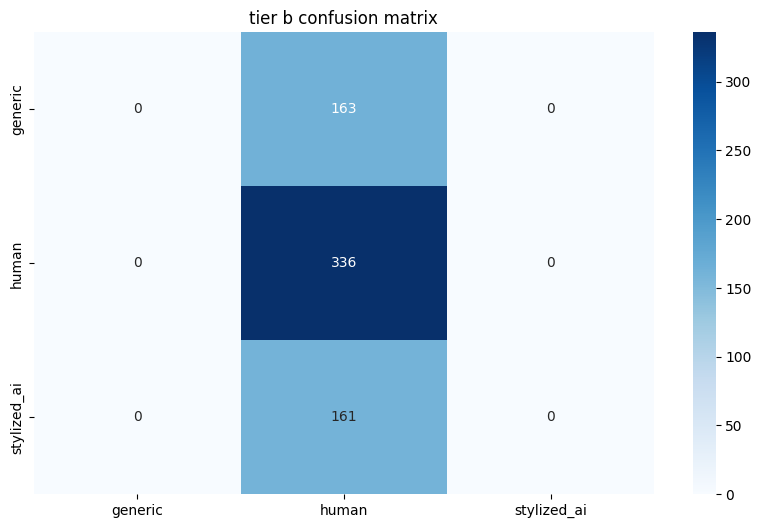

In [2]:
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sb
from tqdm import tqdm

root=Path.cwd().parent
output=root/"data"/"plots"
output.mkdir(parents=True,exist_ok=True)

pathglove=root/"data"/"dolma_300_2024_1.2M.100_combined.txt"
dim=300

def loadglove(file):
    emb={}
    with open(file,encoding="utf-8") as f:
        for line in tqdm(f,desc="loading glove"):
            parts=line.split()
            emb[parts[0]]=np.array(parts[1:],dtype="float32")
    return emb

glove=loadglove(pathglove)

def preprocess(text):
    words=[]
    for c in text.lower():
        if c.isalnum():
            words.append(c)
        else:
            words.append(" ")
    return "".join(words).split()

def embed(text):
    vecs=[glove[w] for w in preprocess(text) if w in glove]
    if vecs:
        return np.mean(vecs,axis=0)
    else:
        return np.zeros(dim)

pathmap={
    "human":root/"data"/"human",
    "generic":root/"data"/"generic_ai",
    "stylized_ai":root/"data"/"stylized_ai"
}

embeds,labels,filenames=[],[],[]
for label,path in pathmap.items():
    for file in tqdm(path.glob("*.txt"),desc=label):
        embeds.append(embed(file.read_text(encoding="utf-8")))
        labels.append(label)
        filenames.append(file.name)

embeds=np.array(embeds)
encoder=LabelEncoder()
y=encoder.fit_transform(labels)

topics=np.array([f.split("_")[-2] for f in filenames])
uniquetopics=np.unique(topics)
np.random.default_rng(42).shuffle(uniquetopics)
testtopics=set(uniquetopics[:int(0.2*len(uniquetopics))])

trainmask=~np.isin(topics,list(testtopics))
testmask=np.isin(topics,list(testtopics))

xtrain,xtest=embeds[trainmask],embeds[testmask]
ytrain,ytest=y[trainmask],y[testmask]

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(dim,512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,3)
        )
    def forward(self,x):
        return self.net(x)

if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

model=Net().to(device)

criterion=nn.CrossEntropyLoss()
optim=torch.optim.Adam(model.parameters(),lr=1e-3)

for epoch in range(20):
    model.train()
    xb=torch.FloatTensor(xtrain).to(device)
    yb=torch.LongTensor(ytrain).to(device)
    optim.zero_grad()
    out=model(xb)
    loss=criterion(out,yb)
    loss.backward()
    optim.step()
    print(f"epoch {epoch+1} loss {loss.item()}")

model.eval()
with torch.no_grad():
    preds=model(torch.FloatTensor(xtest).to(device)).argmax(dim=1).cpu().numpy()

acc=accuracy_score(ytest,preds)
print("test accuracy",acc)

cm=confusion_matrix(ytest,preds)
plt.figure(figsize=(10,6))
sb.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title("tier b confusion matrix")
plt.savefig(output/"tierbconfusionmatrix.png")
plt.show()
plt.close()

### Alternate Implementation for Tier B - Gemini Embeddings + ChromaDB

In [ ]:
from importlib import metadata
import time
import os
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import chromadb
from chromadb.config import Settings
from google import genai as gemini
from google.genai import types
from dotenv import load_dotenv
from transformers import AutoTokenizer,AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sb
from tqdm import tqdm

load_dotenv()
root=Path.cwd()
file=root/"data"/"fingerprint_data.csv"
pathchroma=root/"data"/"chromadb"
output=root/"data"/"plots"
pathchroma.mkdir(parents=True,exist_ok=True)
output.mkdir(parents=True,exist_ok=True)

client=gemini.Client(api_key=os.getenv("GEMINI_API_KEY"))
print("gemini loaded")

gemmodel="models/gemini-embedding-001"
dimensions=768
batchsize=32

class classifier(nn.Module):
    def __init__(self,h1,h2,h3,numclasses,dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(dim,h1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h1,h2),
            nn.ReLU(),
            nn.Linear(h2,h3),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h3,numclasses)
        )
    def forward(self,x):
        return self.net(x)

class texttotorch(Dataset):
    def __init__(self,x,y):
        self.x=torch.FloatTensor(x)
        self.y=torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self,index):
        return self.x[index],self.y[index]

if torch.cuda.is_available():
    dev="cuda"
else:
    dev="cpu"

device=torch.device(dev)
print(f"device {device}")

nnmodel=classifier(512,256,64,3,768).to(device)

print("init chromadb")
chromadbclient=chromadb.PersistentClient(path=str(pathchroma))
coll=chromadbclient.get_or_create_collection(
    name="geminiembeddings",
    metadata={"desc":"gemini embeddings for ai detection"}
)
print(f"existing docs {coll.count()}")

def getgeminiembeddings(text):
    for attempt in range(5):
        try:
            res=client.models.embed_content(
                model=gemmodel,
                contents=text
            )
            result=np.array(res.embeddings[0].values)
            return result
        except Exception as e:
            print(e)

def embeddocs(pathmap,collection):
    emb=[]
    ids=[]
    md=[]
    size=100
    dc=0
    for label in pathmap.keys():
        path=pathmap[label]
        files=list(path.glob("*.txt"))
        for file in tqdm(files,desc=f"{label}"):
            text=file.read_text(encoding="utf-8")
            result=getgeminiembeddings(text)
            ids.append(str(dc))
            emb.append(result.tolist())
            md.append({"filename":file.name,"label":label})
            dc+=1
            time.sleep(0.1)
            if len(ids)>=size:
                coll.add(ids=ids,embeddings=emb,metadatas=md)
                ids=[]
                emb=[]
                md=[]
    if ids:
        coll.add(ids=ids,embeddings=emb,metadatas=md)
    print("stored all data in chromadb")
    print(f"{coll.count()} docs embedded")

def filequantity(pathmap):
    c=0
    for label in pathmap.keys():
        path=pathmap[label]
        files=list(path.glob("*.txt"))
        for file in files:
            c+=1
    return c

test=getgeminiembeddings("what is this task")
if test is not None:
    print(f"got {len(test)}")
else:
    print("failed")

pathmap={
    "human":root/"data"/"human",
    "generic":root/"data"/"generic_ai",
    "stylized_ai":root/"data"/"stylized_ai"
}

totalfiles=filequantity(pathmap)
if coll.count()>=totalfiles:
    print(f"found {coll.count()} embeddings")
else:
    embeddocs(pathmap,coll)

print("loading embedded data")
data=coll.get(include=["embeddings","metadatas"])
embeds=np.array(data["embeddings"])
y=[]
for mditem in data["metadatas"]:
    y.append(mditem["label"])
labels=np.array(y)

encodelabel=LabelEncoder()
y=encodelabel.fit_transform(labels)

xtrain,xtest,ytrain,ytest=train_test_split(
    embeds,
    y,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("data split")
print(f"train test {len(xtrain)} {len(xtest)}")

loadtrain=DataLoader(
    texttotorch(xtrain,ytrain),
    batch_size=32,
    shuffle=True
)

loadtest=DataLoader(
    texttotorch(xtest,ytest),
    batch_size=32,
    shuffle=True
)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(nnmodel.parameters(),lr=0.001)

print("training")
trainloss=[]
trainacc=[]

for epoch in range(20):
    nnmodel.train()
    tloss=0
    correct=0
    total=0
    for bx,by in loadtrain:
        bx,by=bx.to(device),by.to(device)
        optimizer.zero_grad()
        outputs=nnmodel(bx)
        loss=criterion(outputs,by)
        loss.backward()
        optimizer.step()
        tloss+=loss.item()
        _,predicted=torch.max(outputs,1)
        correct+=(predicted==by).sum().item()
        total+=by.size(0)
    avgloss=tloss/len(loadtrain)
    acc=correct/total
    trainloss.append(avgloss)
    trainacc.append(acc)
    print(f"epoch {epoch+1} loss {avgloss} acc {acc}")

print("completed training")

nnmodel.eval()
allpreds=[]
alltrue=[]

with torch.no_grad():
    for bx,by in loadtest:
        bx=bx.to(device)
        outputs=nnmodel(bx)
        _,predicted=torch.max(outputs,1)
        allpreds.extend(predicted.cpu().numpy())
        alltrue.extend(by.numpy())

testacc=accuracy_score(alltrue,allpreds)

print("results")
print(f"test acc {testacc}")

print(
    classification_report(
        encodelabel.inverse_transform(alltrue),
        encodelabel.inverse_transform(allpreds)
    )
)

cm=confusion_matrix(alltrue,allpreds)
plt.figure(figsize=(10,6))
sb.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encodelabel.classes_,
    yticklabels=encodelabel.classes_
)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.savefig(output/"tierbconfusionmatrix.png")
plt.close()

print("diagnosis")

print("checking embedding similarity")
traintestsim=cosine_similarity(xtrain[:50],xtest[:50])
maxsims=traintestsim.max(axis=1)
print(f"max similarity mean {maxsims.mean()}")
print(f"samples over threshold {np.sum(maxsims>0.99)}")

print("checking class separation")
for i,label in enumerate(encodelabel.classes_):
    classmask=y==i
    classembeddings=embeds[classmask]
    withinsim=cosine_similarity(classembeddings[:20],classembeddings[:20])
    avgwithin=withinsim[np.triu_indices(20,k=1)].mean()
    print(f"{label} {avgwithin}")

print("file count")
for label,path in pathmap.items():
    count=len(list(path.glob("*.txt")))
    print(f"{label} {count}")

print("random test prediction")
index=np.random.randint(len(xtest))
xsample=torch.FloatTensor(xtest[index]).unsqueeze(0).to(device)
with torch.no_grad():
    outputpred=nnmodel(xsample)
    probs=torch.softmax(outputpred,dim=1)
print(f"true label {encodelabel.classes_[ytest[index]]}")
print(f"probabilities {probs[0].cpu().numpy()}")

### Tier C — Transformer-Based Detector

This tier fine-tunes a pretrained transformer using LoRA for parameter-efficient training.

**How to run:**
- Requires text files and `fingerprint_data.csv`
- GPU recommended; ran in Google Colab
- Model checkpoints are saved locally after training

**Libraries used:**
- `transformers`
- `peft`
- `datasets`

In [ ]:

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset

model_name="distilbert-base-uncased"
print(f"preparing {model_name}")

root=Path().cwd().parent/"data"
path_human=root/"human"
path_generic=root/"generic_ai"
path_stylized=root/"stylized_ai"

file=root/"fingerprint_data.csv"
df=pd.read_csv(file)

labelmap={"human":0,"generic_ai":1,"stylized_ai":2}
df["labels"]=df["label"].map(labelmap)

def extract_doc_id(filename):
    return filename.split("_chunk_")[0]

df["doc_id"]=df["filename"].apply(extract_doc_id)

def gettext(row):
    label=row["labels"]
    filename=row["filename"]

    if label==0:
        folder=path_human
    elif label==1:
        folder=path_generic
    else:
        folder=path_stylized

    if not filename.endswith(".txt"):
        filename=filename+".txt"

    path=folder/filename

    if path.exists():
        return path.read_text(encoding="utf-8")

    # fallback for safety
    matches=list(folder.glob(f"{filename.split('_chunk_')[0]}*"))
    if matches:
        return matches[0].read_text(encoding="utf-8")

    return ""

print("reading files")
df["text"]=df.apply(gettext,axis=1)
df=df[df["text"]!=""]


doc_ids=df["doc_id"].unique()
rng=np.random.default_rng(42)
rng.shuffle(doc_ids)

val_docs=set(doc_ids[:int(0.2*len(doc_ids))])

train_df=df[~df["doc_id"].isin(val_docs)]
val_df=df[df["doc_id"].isin(val_docs)]

print("train docs:",train_df["doc_id"].nunique())
print("validation docs:",val_df["doc_id"].nunique())
print("train samples:",len(train_df))
print("validation samples:",len(val_df))

assert train_df["doc_id"].nunique()>0
assert val_df["doc_id"].nunique()>0
assert not set(train_df["doc_id"])&set(val_df["doc_id"])

train_dataset=Dataset.from_pandas(train_df[["text","labels"]])
val_dataset=Dataset.from_pandas(val_df[["text","labels"]])

tokenizer=AutoTokenizer.from_pretrained(model_name,use_fast=True)

def tokenize_function(examples):
    tokens=tokenizer(
        examples["text"],
        truncation=True,
        max_length=512
    )
    tokens["labels"]=examples["labels"]
    return tokens

print("tokenizing")
tokenized_train=train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)
tokenized_val=val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

base_model=AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

peft_config=LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin","v_lin"]
)

model=get_peft_model(base_model,peft_config)
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./results/distilbert_lora",
    learning_rate=1e-3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available()
)

def compute_metrics(eval_pred):
    logits,labels=eval_pred
    preds=np.argmax(logits,axis=-1)

    precision,recall,f1,_=precision_recall_fscore_support(
        labels,preds,average="weighted"
    )
    acc=accuracy_score(labels,preds)
    return {
        "accuracy":acc,
        "f1":f1,
        "precision":precision,
        "recall":recall
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

print("training started")
trainer.train()

model.save_pretrained("models/distilbert_lora_tuned")
print("saved model to models/distilbert_lora_tuned")


## **Task 3 — The Smoking Gun (SHAP)**

This step analyzes why the transformer model classifies a paragraph as AI or Human by highlighting the most influential tokens using SHAP.

**How to run:**
- Requires the trained LoRA model in `models/distilbert_lora_tuned/`
- Run the cell once
- A SHAP-based bar plot explaining the prediction will be saved to `data/plots/`
**Libraries used:**

- `shap` (saliency attribution)

/Users/monishram/Desktop/precog/ghost-in-the-machine/gitm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading model


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 999.69it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


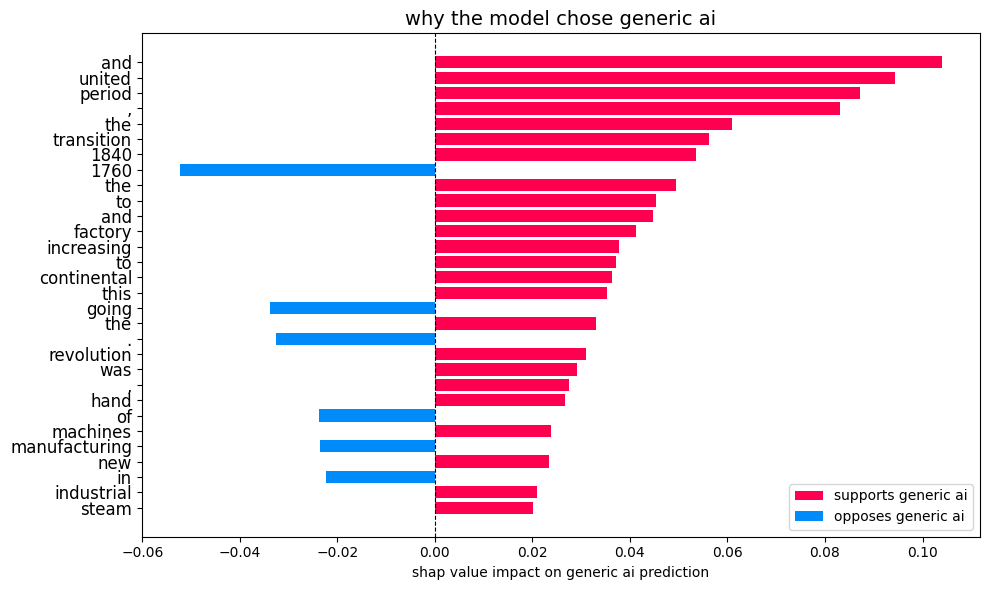

saved explanation for generic ai


In [1]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer,AutoModelForSequenceClassification
from peft import PeftModel,PeftConfig
from pathlib import Path
from matplotlib.patches import Patch

root=Path.cwd().parent
pathplots=root/"data"/"plots"
pathmodel=root/"models"/"distilbert_lora_tuned"

print("loading model")

config=PeftConfig.from_pretrained(pathmodel)
base=AutoModelForSequenceClassification.from_pretrained(
    config.base_model_name_or_path,
    num_labels=3
)
model=PeftModel.from_pretrained(base,pathmodel)
tokenizer=AutoTokenizer.from_pretrained(config.base_model_name_or_path)

model.to("cpu")
model.eval()

para=(
    "The Industrial Revolution was the transition to new manufacturing processes "
    "in Great Britain, continental Europe, and the United States, in the period "
    "from about 1760 to 1840. This transition included going from hand production "
    "methods to machines, new chemical manufacturing and iron production processes, "
    "the increasing use of steam power and water power, the development of machine "
    "tools, and the rise of the mechanized factory system."
)

def predict(texts):
    cleantexts=[]
    for t in texts:
        if isinstance(t,list):
            cleantexts.append(tokenizer.convert_tokens_to_string(t))
        else:
            cleantexts.append(t)

    inputs=tokenizer(
        cleantexts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    with torch.no_grad():
        outputs=model(**inputs)
        probs=torch.softmax(outputs.logits,dim=1)

    return probs.cpu().numpy()

masker=shap.maskers.Text(tokenizer)
explainer=shap.Explainer(predict,masker,algorithm="permutation")

def plottopcontributors(para):
    shapexp=explainer([para])
    valuesall=shapexp.values[0]

    tokens=tokenizer.tokenize(para)
    minlen=min(len(tokens),valuesall.shape[0])
    tokens=tokens[:minlen]
    valuesall=valuesall[:minlen,:]

    totalimpact=np.sum(valuesall,axis=0)
    topclass=int(np.argmax(totalimpact))

    classes=["human","generic ai","stylized ai"]
    targetname=classes[topclass]

    values=valuesall[:,topclass]

    index=np.argsort(np.abs(values))[-30:]
    topvals=values[index]
    toptokens=[tokens[i] for i in index]

    colors=["#ff0051" if v>0 else "#008bfb" for v in topvals]

    plt.figure(figsize=(10,6))
    plt.barh(range(len(topvals)),topvals,color=colors)
    plt.yticks(range(len(topvals)),toptokens,fontsize=12)
    plt.xlabel(f"shap value impact on {targetname} prediction")
    plt.title(f"why the model chose {targetname}",fontsize=14)
    plt.axvline(0,color="black",linewidth=0.8,linestyle="--")

    legend=[
        Patch(facecolor="#ff0051",label=f"supports {targetname}"),
        Patch(facecolor="#008bfb",label=f"opposes {targetname}")
    ]
    plt.legend(handles=legend,loc="lower right",fontsize=10)

    plt.tight_layout()
    filename=pathplots/f"shapexplanation{targetname.replace(' ','')}.png"
    plt.savefig(filename,dpi=300)
    plt.show()
    plt.close()

    print(f"saved explanation for {targetname}")

plottopcontributors(para)

## **Task 4 — The Super-Imposter**

This step attempts to evolve an AI-generated paragraph so that the detector classifies it as Human with high confidence.
A simple genetic algorithm is used, where Gemini acts as a mutation operator and the trained detector provides the fitness score.

**How to run:**
- Requires the trained LoRA detector in `models/distilbert_lora_tuned/`
- Requires a valid Gemini API key set as an environment variable
- Run the cell once
- The final evolved paragraph and its human score are printed

**Libraries used:**
- `google-generativeai`

In [ ]:
import google.generativeai as genai
import time
import torch
import torch.nn.functional as F
import numpy as np
import os
from transformers import AutoModelForSequenceClassification,AutoTokenizer

modelpath="models/distilbert_lora_tuned"
print(f"loading detector from {modelpath}")

model=AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")

if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"

model.to(device)
model.eval()

def gethumanscore(text):
    inputs=tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs=model(**inputs)
        probs=F.softmax(outputs.logits,dim=-1)[0]

    return probs[0].item()

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

availablemodels=[
    m.name
    for m in genai.list_models()
    if "generateContent" in m.supported_generation_methods
]

if "models/gemini-1.5-flash" in availablemodels:
    geminimodel="models/gemini-1.5-flash"
elif "models/gemini-pro" in availablemodels:
    geminimodel="models/gemini-pro"
else:
    geminimodel=availablemodels[0]

print(f"using mutation model {geminimodel}")
mutator=genai.GenerativeModel(geminimodel)

def mutatetext(text,currentscore,generation):
    if currentscore<0.5:
        prompt=(
            "rewrite the following text to sound like a snippet from a classic 1920s novel "
            "in a hemingway like style use concrete sensory details sight sound smell "
            "remove abstract concepts and replace them with physical descriptions "
            "do not use words like therefore or in conclusion "
            f"text {text}"
        )
    else:
        prompt=(
            "rewrite this text to sound more human and casual "
            "vary sentence length add a sentence fragment for effect "
            "use a contraction and break the robotic rhythm without changing the meaning "
            f"text {text}"
        )

    try:
        response=mutator.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(temperature=0.9)
        )
        return response.text.strip()
    except Exception:
        print("api error returning original text")
        return text

def rungeneticalgorithm(starttext,generations=5):
    currenttext=starttext
    print("starting evolution")
    print(f"initial text {currenttext[:80]}")

    for gen in range(generations):
        print(f"generation {gen+1}")
        candidates=[]

        for _ in range(3):
            mutant=mutatetext(currenttext,gethumanscore(currenttext),gen)
            score=gethumanscore(mutant)
            candidates.append((mutant,score))
            time.sleep(1.5)

        candidates.sort(key=lambda x:x[1],reverse=True)
        besttext,bestscore=candidates[0]

        print(f"best human score {bestscore*100}")
        print(f"text sample {besttext[:100]}")

        currenttext=besttext

        if bestscore>0.98:
            print("stopping early high confidence reached")
            break

    return currenttext,bestscore

initialaiparagraph=(
    "in conclusion the integration of artificial intelligence into daily workflows "
    "represents a significant technological advancement it facilitates the automation "
    "of repetitive tasks thereby allowing human operators to focus on complex problem solving"
)

finaltext,finalscore=rungeneticalgorithm(initialaiparagraph)

print("final evolved text")
print(finaltext)
print(f"final human score {finalscore*100}")

### Conclusion

This notebook demonstrates an end-to-end system for authorship detection, progressing from surface-level statistical features to deep transformer-based models. The experiments highlight how genre bias, topic leakage, and stylistic cues can strongly influence model predictions, sometimes more than true authorship signals.